# AI Development Index — Interactive Weights GUI (G7 + China)

Interactive composite AI development score for **G7 + China**, with sliders for adjusting each dimension's weight in real time.

This notebook reads the dataset list from [`data/g7_china_datasets.csv`](../data/g7_china_datasets.csv) (generated by [`select_g7_china_data.ipynb`](select_g7_china_data.ipynb)) and only uses figures available there.

**Requirements**: `ipywidgets` must be installed.

```bash
pip install ipywidgets pandas matplotlib
```


## 1. Setup

In [61]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, clear_output

plt.rcParams['axes.unicode_minus'] = False

# Walk up from cwd until we find the repo root (folder containing `data/`)
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').is_dir():
            return p
    raise FileNotFoundError('Could not locate repo root containing `data/`')

repo_root = find_repo_root(Path.cwd())
index_csv = repo_root / 'data' / 'number' / 'g7_china_datasets.csv'

assert index_csv.exists(), (
    f'{index_csv} not found. Run select_g7_china_data.ipynb first.'
)
print(f'Repo root:  {repo_root}')
print(f'Index file: {index_csv}')


Repo root:  /home/wucheng/AI-Policy
Index file: /home/wucheng/AI-Policy/data/number/g7_china_datasets.csv


## 2. Load the G7+China Dataset Index

`g7_china_datasets.csv` lists every CSV under the Stanford AI Index 2026 public data that contains at least 4 of the G7+China countries.


In [62]:
dataset_index = pd.read_csv(index_csv)
print(f'Loaded {len(dataset_index)} G7+China datasets')
dataset_index.head()


Loaded 64 G7+China datasets


,chapter,figure,country_count,countries_found,rows,columns,column_names,relative_path
0,1. Research and Development,fig_1.1.3,8,United States; China; United Kingdom; France; ...,30,2,"Geographic area, Number of notable machine lea...",data/number/PUBLIC DATA_ 2026 AI INDEX REPORT/...
1,1. Research and Development,fig_1.3.1,8,United States; China; United Kingdom; France; ...,97,3,"Country, num_datacenters, iso_code",data/number/PUBLIC DATA_ 2026 AI INDEX REPORT/...
2,1. Research and Development,fig_1.3.2,8,United States; China; United Kingdom; France; ...,15,2,"Number of Data Centers, Country",data/number/PUBLIC DATA_ 2026 AI INDEX REPORT/...
3,1. Research and Development,fig_1.7.7,8,United States; China; United Kingdom; France; ...,31,3,"Country, Proximity_to_United_States, Proximity...",data/number/PUBLIC DATA_ 2026 AI INDEX REPORT/...
4,1. Research and Development,fig_1.8.1,7,United States; United Kingdom; France; Germany...,21,2,Number of top AI authors and inventors (in tho...,data/number/PUBLIC DATA_ 2026 AI INDEX REPORT/...


## 3. Country & Helper Definitions

In [63]:
COUNTRIES = ['United States', 'China', 'United Kingdom', 'France', 'Germany', 'Italy', 'Japan', 'Canada']

ALIASES = {
    'United States of America': 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
}

COLORS = {
    'United States': '#1f77b4',
    'China':         '#d62728',
    'United Kingdom':'#2ca02c',
    'France':        '#9467bd',
    'Germany':       '#8c564b',
    'Italy':         '#e377c2',
    'Japan':         '#ff7f0e',
    'Canada':        '#17becf',
}


def load_figure(figure_id):
    """Load a CSV by figure id, looked up via the G7+China index."""
    match = dataset_index[dataset_index['figure'] == figure_id]
    if len(match) == 0:
        raise ValueError(
            f'{figure_id} not in g7_china_datasets.csv '
            f'(it does not contain enough G7+China countries)'
        )
    rel = match.iloc[0]['relative_path']
    path = repo_root / rel
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='latin1')


def _to_number(x):
    """Coerce a value to float, stripping % signs and thousands separators."""
    if pd.isna(x):
        return 0.0
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip().replace(',', '').rstrip('%').strip()
    try:
        return float(s)
    except ValueError:
        return 0.0


def extract_g7_china(df, country_col, value_col):
    """Return one value per G7+China country (0 if missing)."""
    df = df.copy()
    df[country_col] = df[country_col].replace(ALIASES)
    sub = df[df[country_col].isin(COUNTRIES)]
    result = {}
    for c in COUNTRIES:
        match = sub[sub[country_col] == c]
        result[c] = _to_number(match[value_col].iloc[0]) if len(match) > 0 else 0.0
    return result


print('Helpers ready')


Helpers ready


## 4. Define Indicators (7 Dimensions)

Each dimension uses **one figure from the G7+China index**. The `(figure_id, country_column, value_column)` tuples below are the only configuration — change them to swap indicators.


In [64]:
INDICATOR_CONFIG = {
    'Infrastructure': ('fig_1.3.2', 'Country',          'Number of Data Centers'),
    'R&D Output':     ('fig_1.1.3', 'Geographic area',  'Number of notable machine learning models'),
    'Talent':         ('fig_1.8.1', 'Country',          'Number of top AI authors and inventors (in thousands)'),
    'Investment':     ('fig_4.2.12','Country',          'Total Investment (in Billions of U.S. Dollars)'),
    'Industry':       ('fig_4.2.13','Country',          'Number of Companies'),
    'Adoption':       ('fig_4.3.10','Country',          'H2 2025 AI Diffusion (%)'),
    'Policy':         ('fig_8.4.3', 'Country',          'Number of AI-related bills passed into law, 2016\u201325 (sum)'),
}

# Verify all figures are in the G7+China index
missing = [name for name, (fig, _, _) in INDICATOR_CONFIG.items()
           if fig not in dataset_index['figure'].values]
if missing:
    print(f'WARNING: {missing} not in g7_china_datasets.csv')
else:
    print('All indicator figures verified in G7+China index')


All indicator figures verified in G7+China index


## 5. Load Raw Indicator Values

In [65]:
raw = {}
for dim, (fig, ccol, vcol) in INDICATOR_CONFIG.items():
    df = load_figure(fig)
    raw[dim] = extract_g7_china(df, ccol, vcol)

raw_df = pd.DataFrame(raw)
print('Raw indicator values for G7 + China:')
display(raw_df.round(2))


Raw indicator values for G7 + China:


,Infrastructure,R&D Output,Talent,Investment,Industry,Adoption,Policy
United States,5427.0,627.0,220.52,757.27,8909.0,0.0,25.0
China,449.0,144.0,0.00,131.83,1766.0,0.0,1.0
United Kingdom,523.0,41.0,34.37,34.07,1057.0,0.0,6.0
France,322.0,23.0,18.82,15.57,552.0,0.0,10.0
Germany,529.0,24.0,48.52,17.16,486.0,0.0,5.0
Italy,168.0,1.0,13.23,0.00,0.0,0.0,9.0
Japan,222.0,10.0,6.28,7.00,444.0,0.0,10.0
Canada,337.0,53.0,31.45,19.59,560.0,0.0,1.0


## 6. Normalize (max = 100)

In [66]:
def normalize(df):
    norm = df.copy().astype(float)
    for col in norm.columns:
        col_max = norm[col].max()
        norm[col] = (norm[col] / col_max * 100) if col_max > 0 else 0
    return norm.round(1)


norm_df = normalize(raw_df)
print('Normalized scores (0-100, 100 = best in this group):')
display(norm_df)


Normalized scores (0-100, 100 = best in this group):


,Infrastructure,R&D Output,Talent,Investment,Industry,Adoption,Policy
United States,100.0,100.0,100.0,100.0,100.0,0,100.0
China,8.3,23.0,0.0,17.4,19.8,0,4.0
United Kingdom,9.6,6.5,15.6,4.5,11.9,0,24.0
France,5.9,3.7,8.5,2.1,6.2,0,40.0
Germany,9.7,3.8,22.0,2.3,5.5,0,20.0
Italy,3.1,0.2,6.0,0.0,0.0,0,36.0
Japan,4.1,1.6,2.8,0.9,5.0,0,40.0
Canada,6.2,8.5,14.3,2.6,6.3,0,4.0


## 7. Composite AI Development Score Analysis

This cell calculates a composite AI development score for each country based on manually assigned weights across multiple evaluation dimensions.

### Methodology

1. A weight is manually assigned to each dimension (e.g., Compute, Talent, Data, Policy, Infrastructure).
2. The weights are automatically normalized so that their total equals 100%.
3. A weighted sum is computed using the normalized indicator values in `norm_df`.
4. Countries are ranked according to their final composite scores.

### Outputs

The cell generates:

- A table showing the raw and normalized weights for each dimension.
- A ranking table of countries based on the composite AI development score.
- A horizontal bar chart visualizing the ranking results.
- A radar chart comparing the multidimensional profiles of the top four countries.

### Purpose

This analysis enables flexible exploration of how different strategic priorities influence the overall AI development ranking. By manually adjusting the weights, users can examine the sensitivity of rankings to different policy or capability assumptions.


Weights:


,Raw Weight,Normalized Weight (%)
Infrastructure,1,14.3
R&D Output,1,14.3
Talent,1,14.3
Investment,1,14.3
Industry,1,14.3
Adoption,1,14.3
Policy,1,14.3


Composite AI Development Score:


,Rank,Composite Score
United States,1,85.71
China,2,10.36
United Kingdom,3,10.30
France,4,9.49
Germany,5,9.04
Japan,6,7.77
Italy,7,6.47
Canada,8,5.99


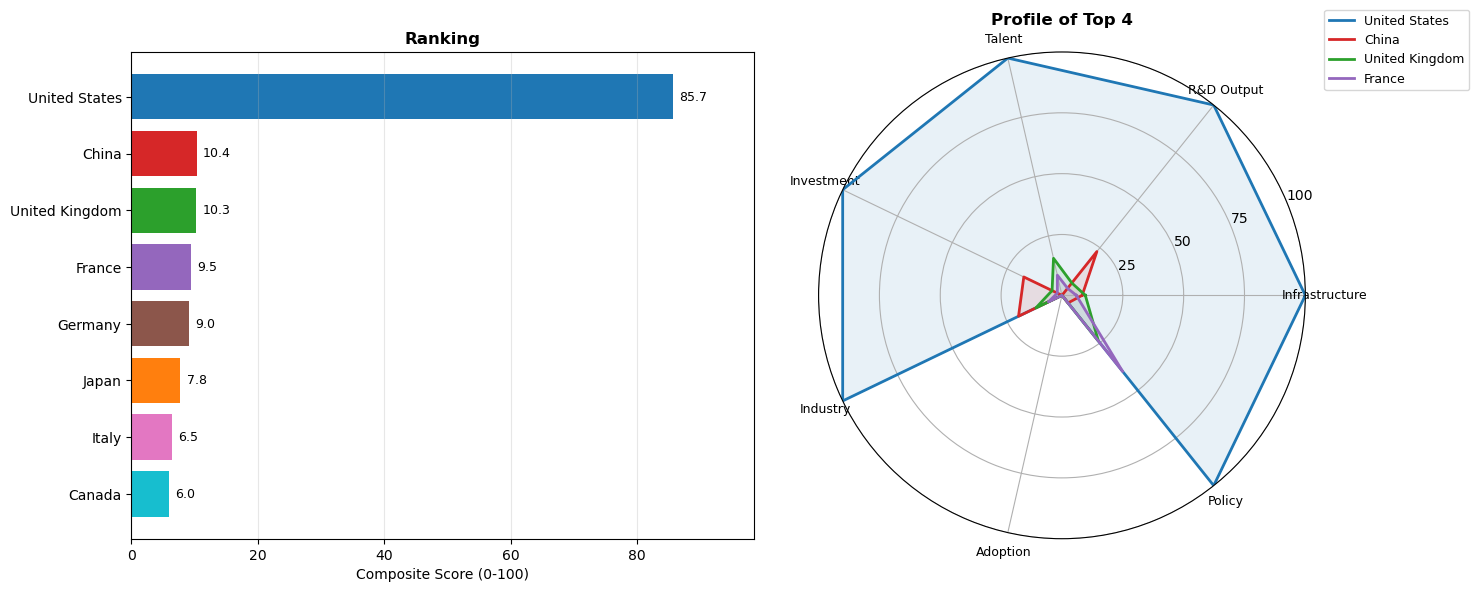

In [67]:

# =========================
# Manual Weight Setting
# =========================
weights = {
    "Infrastructure": 1,
    "R&D Output": 1,
    "Talent": 1,
    "Investment": 1,
    "Industry": 1,
    "Adoption": 1,
    "Policy": 1,
}

# 确保顺序与 norm_df.columns 一致
weights = {
    dim: weights.get(dim, 0)
    for dim in norm_df.columns
}


# =========================
# Normalize Weights
# =========================
total = sum(weights.values())

if total == 0:
    raise ValueError("Total weight cannot be zero.")

norm_weights = {
    k: v / total
    for k, v in weights.items()
}


# =========================
# Compute Composite Score
# =========================
scores = pd.Series(
    0.0,
    index=norm_df.index
)

for dim, w in norm_weights.items():
    scores += norm_df[dim] * w

scores = scores.sort_values(ascending=False)


# =========================
# Show Weight Table
# =========================
weight_df = pd.DataFrame({
    "Raw Weight": weights,
    "Normalized Weight (%)": {
        k: round(v * 100, 1)
        for k, v in norm_weights.items()
    }
})

print("Weights:")
display(weight_df)


# =========================
# Ranking Table
# =========================
score_df = pd.DataFrame({
    "Composite Score": scores.round(2)
})

score_df.insert(
    0,
    "Rank",
    range(1, len(score_df) + 1)
)

print("Composite AI Development Score:")
display(score_df)


# =========================
# Visualization
# =========================
fig = plt.figure(figsize=(15, 6))

gs = GridSpec(
    1,
    2,
    width_ratios=[1.1, 1]
)

# =========================
# Left: Ranking Bar Chart
# =========================
ax1 = fig.add_subplot(gs[0])

colors = [
    COLORS.get(c, "gray")
    for c in scores.index
]

ax1.barh(
    scores.index[::-1],
    scores.values[::-1],
    color=colors[::-1]
)

ax1.set_xlabel("Composite Score (0-100)")

ax1.set_title(
    "Ranking",
    fontsize=12,
    fontweight="bold"
)

ax1.grid(axis="x", alpha=0.3)

for i, v in enumerate(scores.values[::-1]):
    ax1.text(
        v + 1,
        i,
        f"{v:.1f}",
        va="center",
        fontsize=9
    )

xmax = max(scores.values) * 1.15 if scores.max() > 0 else 1
ax1.set_xlim(0, xmax)


# =========================
# Right: Radar Chart
# =========================
ax2 = fig.add_subplot(
    gs[1],
    projection="polar"
)

top4 = scores.head(4).index.tolist()

DIMENSIONS = list(norm_df.columns)

N = len(DIMENSIONS)

angles = [
    n / N * 2 * np.pi
    for n in range(N)
]

angles += angles[:1]

for country in top4:

    vals = norm_df.loc[country].tolist()
    vals += vals[:1]

    color = COLORS.get(country, "gray")

    ax2.plot(
        angles,
        vals,
        linewidth=2,
        label=country,
        color=color
    )

    ax2.fill(
        angles,
        vals,
        alpha=0.1,
        color=color
    )

ax2.set_xticks(angles[:-1])

ax2.set_xticklabels(
    DIMENSIONS,
    fontsize=9
)

ax2.set_ylim(0, 100)

ax2.set_yticks([25, 50, 75, 100])

ax2.set_title(
    "Profile of Top 4",
    fontsize=12,
    fontweight="bold",
    pad=20
)

ax2.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.1),
    fontsize=9
)

ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Export Current Result

In [70]:

scores, norm_w = compute_scores(weights)

result = pd.DataFrame({
    'Country': scores.index,
    'Composite Score': scores.values.round(2),
    'Rank': range(1, len(scores) + 1),
})

out_path = repo_root / 'data' / 'number' / 'ai_dev_index_g7_china.csv'
result.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print('\nWeights used:')
for d, w in norm_w.items():
    print(f'  {d}: {w*100:.1f}%')
print()
display(result)


Saved: /home/wucheng/AI-Policy/data/number/ai_dev_index_g7_china.csv

Weights used:
  Infrastructure: 14.3%
  R&D Output: 14.3%
  Talent: 14.3%
  Investment: 14.3%
  Industry: 14.3%
  Adoption: 14.3%
  Policy: 14.3%



,Country,Composite Score,Rank
0,United States,85.71,1
1,China,10.36,2
2,United Kingdom,10.30,3
3,France,9.49,4
4,Germany,9.04,5
5,Japan,7.77,6
6,Italy,6.47,7
7,Canada,5.99,8


## 9. Browse Other Available G7+China Datasets

If you want to swap an indicator, look here for candidates and edit `INDICATOR_CONFIG` above.


In [ ]:
dataset_index[['chapter', 'figure', 'country_count', 'rows', 'columns', 'column_names']]
